# Notebook 06 - Embeddings V1 (Sentence-Transformers)

**Objectif**: Calculer des embeddings d'énoncés avec Sentence-Transformers et réaliser une analyse exploratoire centrée sur les embeddings.

**Modèle**: `sentence-transformers/all-MiniLM-L6-v2` (384 dimensions)

**Pipeline**:
1. Chargement du dataset préprocessé
2. Identification des labels binaires (8 tags prioritaires, déjà dans le dataset)
3. Preprocessing texte: LaTeX → tokens, normalisation, **conservation des nombres**
4. Troncature simple (budget max de mots)
5. Calcul des embeddings
6. Analyse des centroids par label
7. Distributions de similarité cosine (positifs vs négatifs)

**Livrables**:
- `embeddings`: matrice (n_docs, 384) normalisée L2
- `centroids`: dict {tag: vecteur centroid}
- `centroid_sim_matrix`: matrice 8x8 de similarité cosine entre centroids
- Figures: heatmap centroids, distributions par label


In [2]:
!uv pip install sentence_transformers

Using Python 3.13.11 environment at: /app/.venv
Resolved 46 packages in 915ms                                        
Prepared 30 packages in 3m 18s                                           
Uninstalled 1 package in 61ms
░░░░░░░░░░░░░░░░░░░░ [0/30] Installing wheels...                                warning: Failed to hardlink files; falling back to full copy. This may lead to degraded performance.
         If the cache and target directories are on different filesystems, hardlinking may not be supported.
         If this is intentional, set `export UV_LINK_MODE=copy` or use `--link-mode=copy` to suppress this warning.
Installed 30 packages in 44.68s                             
 + filelock==3.20.3
 + fsspec==2026.1.0
 + hf-xet==1.2.0
 + huggingface-hub==0.36.0
 + mpmath==1.3.0
 + networkx==3.6.1
 + nvidia-cublas-cu12==12.8.4.1
 + nvidia-cuda-cupti-cu12==12.8.90
 + nvidia-cuda-nvrtc-cu12==12.8.93
 + nvidia-cuda-runtime-cu12==12.8.90
 + nvidia-cudnn-cu12==9.10.2.21
 + nvidia-cufft-cu12

---
## 1. Imports & Configuration


In [7]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm

# Configuration
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Seed pour reproductibilité
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Tags prioritaires
PRIORITY_TAGS = [
    'math',
    'graphs',
    'strings',
    'number theory',
    'trees',
    'geometry',
    'games',
    'probabilities'
]

# Chemins
DATA_DIR = Path('../data/processed')
OUTPUTS_DIR = Path('../docs/embeddings')
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

print("Configuration OK")
print(f"Tags prioritaires: {len(PRIORITY_TAGS)}")
print(f"Output directory: {OUTPUTS_DIR}")


Configuration OK
Tags prioritaires: 8
Output directory: ../docs/embeddings


---
## 2. Chargement du Dataset Préprocessé

On charge le dataset issu du notebook `04_preprocessing_pipeline.ipynb`.

**Colonnes attendues**:
- `unified_document`: texte concaténé avec LaTeX
- `tags`: liste de tags originaux


In [8]:
# Chargement du dataset train (on travaille sur le train pour l'EDA)
train_path = DATA_DIR / 'train_preprocessed.parquet'

if not train_path.exists():
    raise FileNotFoundError(f"Dataset non trouvé: {train_path}")

df = pd.read_parquet(train_path)

print(f"Dataset chargé: {len(df)} documents")
print(f"Colonnes: {df.columns.tolist()}")

# Vérifications
assert 'unified_document' in df.columns, "Colonne 'unified_document' manquante"
assert 'tags' in df.columns, "Colonne 'tags' manquante"

# Aperçu
print("\nAperçu du dataset:")
df[['unified_document', 'tags']].head(3)


Dataset chargé: 3979 documents
Colonnes: ['prob_desc_time_limit', 'prob_desc_sample_outputs', 'src_uid', 'prob_desc_notes', 'prob_desc_description', 'prob_desc_output_spec', 'prob_desc_input_spec', 'prob_desc_output_to', 'prob_desc_input_from', 'lang', 'lang_cluster', 'difficulty', 'file_name', 'code_uid', 'prob_desc_memory_limit', 'prob_desc_sample_inputs', 'exec_outcome', 'source_code', 'prob_desc_created_at', 'tags', 'hidden_unit_tests', 'prob_desc_description_translated', 'prob_desc_input_spec_translated', 'prob_desc_output_spec_translated', 'prob_desc_notes_translated', 'prob_desc_description_translated_hash', 'time_limit_seconds', 'clean_description', 'latex_features_desc', 'nb_latex_blocks', 'nb_latex_symbols', 'latex_density', 'latex_symbols_density', 'has_le', 'has_ldots', 'has_dots', 'has_leq', 'has_cdot', 'has_times', 'has_ne', 'has_frac', 'has_ge', 'has_sum', 'has_neq', 'has_limits', 'has_max', 'has_right', 'has_oplus', 'has_lfloor', 'has_rfloor', 'has_in', 'has_min', 'has_

,unified_document,tags
0,"[DESC] Numbers $$$1, 2, 3, \dots n$$$ (each in...","[greedy, constructive algorithms, math, implem..."
1,[DESC] There are $$$n$$$ positive integers $$$...,"[number theory, greedy]"
2,[DESC] You are given an undirected graph consi...,"[dsu, greedy, graphs]"


---
## 3. Identification des Labels Binaires (8 Tags Prioritaires)

Le dataset préprocessé contient déjà les colonnes `target_{tag}` pour les 8 tags prioritaires.
On identifie simplement ces colonnes pour les analyses ultérieures.


In [9]:
# Identifier les colonnes target existantes
label_columns = []
for tag in PRIORITY_TAGS:
    col_name = f'target_{tag}'
    if col_name in df.columns:
        label_columns.append(col_name)
    else:
        print(f"⚠️  Colonne {col_name} non trouvée!")

# Vérification
assert len(label_columns) == len(PRIORITY_TAGS), f"Nombre de colonnes incorrect: {len(label_columns)}/{len(PRIORITY_TAGS)}"

print("Labels binaires identifiés:")
print("="*80)
for tag, col in zip(PRIORITY_TAGS, label_columns):
    n_pos = df[col].sum()
    pct_pos = (n_pos / len(df)) * 100
    print(f"  {col:25s}: {n_pos:4d} positifs ({pct_pos:5.2f}%)")

print("="*80)
print(f"Total documents: {len(df)}")


Labels binaires identifiés:
  target_math              : 1127 positifs (28.32%)
  target_graphs            :  444 positifs (11.16%)
  target_strings           :  342 positifs ( 8.60%)
  target_number theory     :  285 positifs ( 7.16%)
  target_trees             :  255 positifs ( 6.41%)
  target_geometry          :  128 positifs ( 3.22%)
  target_games             :   87 positifs ( 2.19%)
  target_probabilities     :   77 positifs ( 1.94%)
Total documents: 3979


---
## 4. Preprocessing du Texte

**Objectif**: Nettoyer le texte pour les embeddings en:
1. Remplaçant les blocs LaTeX par `MATHBLOCK`
2. Remplaçant les commandes LaTeX spécifiques par des tokens (ex: `\gcd` → `LATEX_GCD`)
3. Normalisant les espaces
4. Appliquant un lowercase

**IMPORTANT**: Contrairement au TF-IDF, on **ne tokenise PAS les nombres** ici. Les embeddings peuvent tirer parti des valeurs numériques dans leur contexte.


In [ ]:
# Commandes LaTeX à remplacer par des tokens
LATEX_COMMANDS_TO_TOKEN = {
    r'\\gcd': 'LATEX_GCD',
    r'\\lcm': 'LATEX_LCM',
    r'\\binom': 'LATEX_BINOM',
    r'\\Pr': 'LATEX_PR',
    r'\\sqrt': 'LATEX_SQRT',
    r'\\sum': 'LATEX_SUM',
    r'\\prod': 'LATEX_PROD',
    r'\\log': 'LATEX_LOG',
    r'\\sin': 'LATEX_SIN',
    r'\\cos': 'LATEX_COS',
    r'\\tan': 'LATEX_TAN',
    r'\\min': 'LATEX_MIN',
    r'\\max': 'LATEX_MAX',
}

def clean_text_for_embeddings(text: str, replace_latex: bool = True) -> str:
    """
    Nettoie le texte pour les embeddings.
    
    Différences avec clean_text pour TF-IDF:
    - PAS de tokenisation des nombres
    - Traitement LaTeX paramétrable
    
    Parameters
    ----------
    text : str
        Texte brut avec LaTeX
    replace_latex : bool, default=True
        Si True, remplace le LaTeX par des tokens (MATHBLOCK, LATEX_GCD, etc.)
        Si False, garde le LaTeX brut (utile pour SPECTER)
        
    Returns
    -------
    str
        Texte nettoyé
    """
    if pd.isna(text):
        return ""
    
    text = str(text)
    
    if replace_latex:
        # 1. Remplacer les blocs LaTeX par MATHBLOCK
        text = re.sub(r'\$\$\$.*?\$\$\$', ' MATHBLOCK ', text, flags=re.DOTALL)
        text = re.sub(r'\$\$.*?\$\$', ' MATHBLOCK ', text, flags=re.DOTALL)
        text = re.sub(r'\$.*?\$', ' MATHBLOCK ', text, flags=re.DOTALL)
        text = re.sub(r'\\\[.*?\\\]', ' MATHBLOCK ', text, flags=re.DOTALL)
        text = re.sub(r'\\\(.*?\\\)', ' MATHBLOCK ', text, flags=re.DOTALL)
        
        # 2. Remplacer commandes LaTeX spécifiques
        for latex_cmd, token in LATEX_COMMANDS_TO_TOKEN.items():
            text = re.sub(latex_cmd, f' {token} ', text, flags=re.IGNORECASE)
    
    # 3. Normaliser les espaces (toujours fait)
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    
    # 4. Lowercase (toujours fait)
    text = text.lower()
    
    return text

# Test de la fonction
test_text = "Calculate $\\gcd(a, b)$ where $a = 123$ and $b = 456$. The sum is $\\sum_{i=1}^{n} i$."
print("Exemple de nettoyage:")
print(f"Avant: {test_text}")
print(f"Après: {clean_text_for_embeddings(test_text)}")

# Application au dataset
print("\nApplication du preprocessing au dataset...")
df['unified_document_clean'] = df['unified_document'].apply(clean_text_for_embeddings)

# Statistiques
print("\nStatistiques après preprocessing:")
df['text_length_words'] = df['unified_document_clean'].apply(lambda x: len(x.split()))
print(f"Longueur en mots:")
print(f"  Min:    {df['text_length_words'].min()}")
print(f"  Q25:    {df['text_length_words'].quantile(0.25):.0f}")
print(f"  Median: {df['text_length_words'].median():.0f}")
print(f"  Q75:    {df['text_length_words'].quantile(0.75):.0f}")
print(f"  P95:    {df['text_length_words'].quantile(0.95):.0f}")
print(f"  Max:    {df['text_length_words'].max()}")

# Exemples
print("\nExemples de textes nettoyés:")
for i in range(3):
    print(f"\nExemple {i+1} (longueur: {df.iloc[i]['text_length_words']} mots):")
    print(df.iloc[i]['unified_document_clean'][:300] + "...")


Exemple de nettoyage:
Avant: Calculate $\gcd(a, b)$ where $a = 123$ and $b = 456$. The sum is $\sum_{i=1}^{n} i$.
Après: calculate mathblock where mathblock and mathblock . the sum is mathblock .

Application du preprocessing au dataset...

Statistiques après preprocessing:
Longueur en mots:
  Min:    74
  Q25:    255
  Median: 332
  Q75:    420
  P95:    580
  Max:    1156

Exemples de textes nettoyés:

Exemple 1 (longueur: 254 mots):
[desc] numbers mathblock (each integer from mathblock to mathblock once) are written on a board. in one operation you can erase any two numbers mathblock and mathblock from the board and write one integer mathblock rounded up instead.you should perform the given operation mathblock times and make th...

Exemple 2 (longueur: 276 mots):
[desc] there are mathblock positive integers mathblock . for the one move you can choose any even value mathblock and divide by two all elements that equal mathblock .for example, if mathblock and you choose mathblock , and

---
## 5. Troncature Simple

Les modèles Sentence-Transformers ont une limite de tokens (typiquement 256-512 pour MiniLM).

On applique une troncature simple:
- Garder les premiers `max_words` mots
- Valeur par défaut: 400 mots (~ 512 tokens avec marge)

**Note**: Une approche plus sophistiquée pourrait utiliser du chunking + pooling, mais on reste simple en V1.


In [11]:
def truncate_text(text: str, max_words: int = 400) -> str:
    """
    Tronque le texte aux premiers max_words mots.
    
    Parameters
    ----------
    text : str
        Texte à tronquer
    max_words : int, default=400
        Nombre maximum de mots à conserver
        
    Returns
    -------
    str
        Texte tronqué
    """
    if pd.isna(text):
        return ""
    
    words = str(text).split()
    if len(words) <= max_words:
        return text
    
    return ' '.join(words[:max_words])

# Application
MAX_WORDS = 400
print(f"Application de la troncature (max_words={MAX_WORDS})...")

df['unified_document_trunc'] = df['unified_document_clean'].apply(
    lambda x: truncate_text(x, max_words=MAX_WORDS)
)
# Statistiques post-troncature
df['text_length_words_after'] = df['unified_document_trunc'].apply(lambda x: len(x.split()))

n_truncated = (df['text_length_words'] > MAX_WORDS).sum()
pct_truncated = (n_truncated / len(df)) * 100

print(f"\nStatistiques post-troncature:")
print(f"  Documents tronqués: {n_truncated} / {len(df)} ({pct_truncated:.2f}%)")
print(f"\nLongueur en mots (après troncature):")
print(f"  Min:    {df['text_length_words_after'].min()}")
print(f"  Median: {df['text_length_words_after'].median():.0f}")
print(f"  P95:    {df['text_length_words_after'].quantile(0.95):.0f}")
print(f"  Max:    {df['text_length_words_after'].max()}")

# Exemple de document tronqué
if n_truncated > 0:
    idx_trunc = df[df['text_length_words'] > MAX_WORDS].index[0]
    print(f"\nExemple de document tronqué (index {idx_trunc}):")
    print(f"  Longueur avant: {df.loc[idx_trunc, 'text_length_words']} mots")
    print(f"  Longueur après: {df.loc[idx_trunc, 'text_length_words_after']} mots")
    print(f"  Texte: {df.loc[idx_trunc, 'unified_document_trunc'][:200]}...")


Application de la troncature (max_words=400)...

Statistiques post-troncature:
  Documents tronqués: 1169 / 3979 (29.38%)

Longueur en mots (après troncature):
  Min:    74
  Median: 332
  P95:    400
  Max:    400

Exemple de document tronqué (index 7):
  Longueur avant: 420 mots
  Longueur après: 400 mots
  Texte: [desc] in summer informatics school, if a student doesn't behave well, teachers make a hole in his badge. and today one of the teachers caught a group of mathblock students doing yet another trick. le...


---
## 6. Calcul des Embeddings avec MiniLM

**Modèle**: `sentence-transformers/all-MiniLM-L6-v2`
- Dimensions: 384
- Max sequence length: 256 tokens (notre troncature à 400 mots devrait passer)
- Performances: bon compromis vitesse/qualité

**Paramètres d'encoding**:
- `batch_size=64`: traitement par batch pour efficacité
- `show_progress_bar=True`: affichage de la progression
- `convert_to_numpy=True`: sortie en numpy array
- `normalize_embeddings=True`: normalisation L2 (cosine similarity = dot product)


In [12]:
# Chargement du modèle
print("Chargement du modèle Sentence-Transformers...")
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
print(f"Modèle chargé: {model.get_sentence_embedding_dimension()} dimensions")

# Préparation des textes
texts = df['unified_document_trunc'].fillna("").tolist()
print(f"\nEncoding de {len(texts)} documents...")

# Encoding
embeddings = model.encode(
    texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True  # Normalisation L2
)

# Vérifications
print(f"\nEmbeddings calculés:")
print(f"  Shape: {embeddings.shape}")
print(f"  Dtype: {embeddings.dtype}")
print(f"  Norme L2 (premier doc): {np.linalg.norm(embeddings[0]):.6f}")
print(f"  Memory: {embeddings.nbytes / 1024**2:.2f} MB")

# Vérifier la normalisation
norms = np.linalg.norm(embeddings, axis=1)
print(f"\nVérification normalisation L2:")
print(f"  Min norm: {norms.min():.6f}")
print(f"  Max norm: {norms.max():.6f}")
print(f"  Mean norm: {norms.mean():.6f}")

Chargement du modèle Sentence-Transformers...
Modèle chargé: 384 dimensions

Encoding de 3979 documents...


Batches: 100%|██████████| 63/63 [02:38<00:00,  2.51s/it]


Embeddings calculés:
  Shape: (3979, 384)
  Dtype: float32
  Norme L2 (premier doc): 1.000000
  Memory: 5.83 MB

Vérification normalisation L2:
  Min norm: 1.000000
  Max norm: 1.000000
  Mean norm: 1.000000


### Sauvegarde des Embeddings (optionnel)


In [13]:
# Sauvegarde (optionnel)
embeddings_path = DATA_DIR / 'embeddings_minilm_train.npy'
np.save(embeddings_path, embeddings)
print(f"Embeddings sauvegardés: {embeddings_path}")

Embeddings sauvegardés: ../data/processed/embeddings_minilm_train.npy


---
## 7. Analyse des Centroids

### 7.1 Calcul des Centroids par Label

Pour chaque tag prioritaire:
1. Sélectionner tous les documents positifs
2. Calculer la moyenne des embeddings → centroid
3. Re-normaliser le centroid (L2)

Le centroid représente le "prototype" d'un document de ce tag dans l'espace d'embeddings.


In [14]:
# Calcul des centroids
centroids = {}

print("Calcul des centroids par label:")
print("="*80)

for tag, col in zip(PRIORITY_TAGS, label_columns):
    # Indices des documents positifs
    pos_idx = df[col] == 1
    n_pos = pos_idx.sum()
    
    if n_pos == 0:
        print(f"⚠️  {tag:20s}: Aucun document positif!")
        centroids[tag] = np.zeros(embeddings.shape[1])
        continue
    
    # Moyenne des embeddings positifs
    centroid = embeddings[pos_idx].mean(axis=0)
    
    # Re-normalisation L2
    centroid_norm = np.linalg.norm(centroid)
    if centroid_norm > 0:
        centroid = centroid / centroid_norm
    
    centroids[tag] = centroid
    
    print(f"✓ {tag:20s}: {n_pos:4d} docs positifs, norm={np.linalg.norm(centroid):.6f}")

print("="*80)
print(f"Centroids calculés pour {len(centroids)} labels")


Calcul des centroids par label:
✓ math                : 1127 docs positifs, norm=1.000000
✓ graphs              :  444 docs positifs, norm=1.000000
✓ strings             :  342 docs positifs, norm=1.000000
✓ number theory       :  285 docs positifs, norm=1.000000
✓ trees               :  255 docs positifs, norm=1.000000
✓ geometry            :  128 docs positifs, norm=1.000000
✓ games               :   87 docs positifs, norm=1.000000
✓ probabilities       :   77 docs positifs, norm=1.000000
Centroids calculés pour 8 labels


### 7.2 Matrice de Similarité Cosine entre Centroids

Cette matrice montre à quel point les différents tags sont "proches" dans l'espace d'embeddings.

**Interprétation**:
- Valeur élevée (proche de 1): les documents des deux tags se ressemblent
- Valeur faible: les documents sont distincts
- Diagonale = 1 (chaque centroid avec lui-même)


In [15]:
# Calcul de la matrice de similarité
centroid_matrix = np.array([centroids[tag] for tag in PRIORITY_TAGS])
centroid_sim_matrix = cosine_similarity(centroid_matrix)

print("Matrice de similarité cosine entre centroids:")
print("="*80)

# Affichage sous forme de tableau
centroid_sim_df = pd.DataFrame(
    centroid_sim_matrix,
    index=PRIORITY_TAGS,
    columns=PRIORITY_TAGS
)
print(centroid_sim_df.round(3))

# Statistiques
print("\nStatistiques (hors diagonale):")
off_diag = centroid_sim_matrix[~np.eye(len(PRIORITY_TAGS), dtype=bool)]
print(f"  Min:    {off_diag.min():.4f}")
print(f"  Mean:   {off_diag.mean():.4f}")
print(f"  Median: {np.median(off_diag):.4f}")
print(f"  Max:    {off_diag.max():.4f}")

# Paires les plus similaires
print("\nTop 5 paires de tags les plus similaires:")
pairs = []
for i in range(len(PRIORITY_TAGS)):
    for j in range(i+1, len(PRIORITY_TAGS)):
        pairs.append((PRIORITY_TAGS[i], PRIORITY_TAGS[j], centroid_sim_matrix[i, j]))

pairs_sorted = sorted(pairs, key=lambda x: x[2], reverse=True)
for i, (tag1, tag2, sim) in enumerate(pairs_sorted[:5], 1):
    print(f"  {i}. {tag1:20s} <-> {tag2:20s}: {sim:.4f}")


Matrice de similarité cosine entre centroids:
                math  graphs  strings  number theory  trees  geometry  games  \
math           1.000   0.891    0.794          0.972  0.803     0.812  0.800   
graphs         0.891   1.000    0.701          0.830  0.944     0.850  0.804   
strings        0.794   0.701    1.000          0.766  0.647     0.588  0.647   
number theory  0.972   0.830    0.766          1.000  0.758     0.749  0.713   
trees          0.803   0.944    0.647          0.758  1.000     0.757  0.718   
geometry       0.812   0.850    0.588          0.749  0.757     1.000  0.709   
games          0.800   0.804    0.647          0.713  0.718     0.709  1.000   
probabilities  0.886   0.857    0.715          0.820  0.794     0.754  0.847   

               probabilities  
math                   0.886  
graphs                 0.857  
strings                0.715  
number theory          0.820  
trees                  0.794  
geometry               0.754  
games           

### 7.3 Heatmap de Similarité entre Centroids


In [16]:
def slugify_tag(tag: str) -> str:
    """Convertit un tag en slug (espaces -> underscores)."""
    return tag.replace(' ', '_').replace('-', '_').lower()


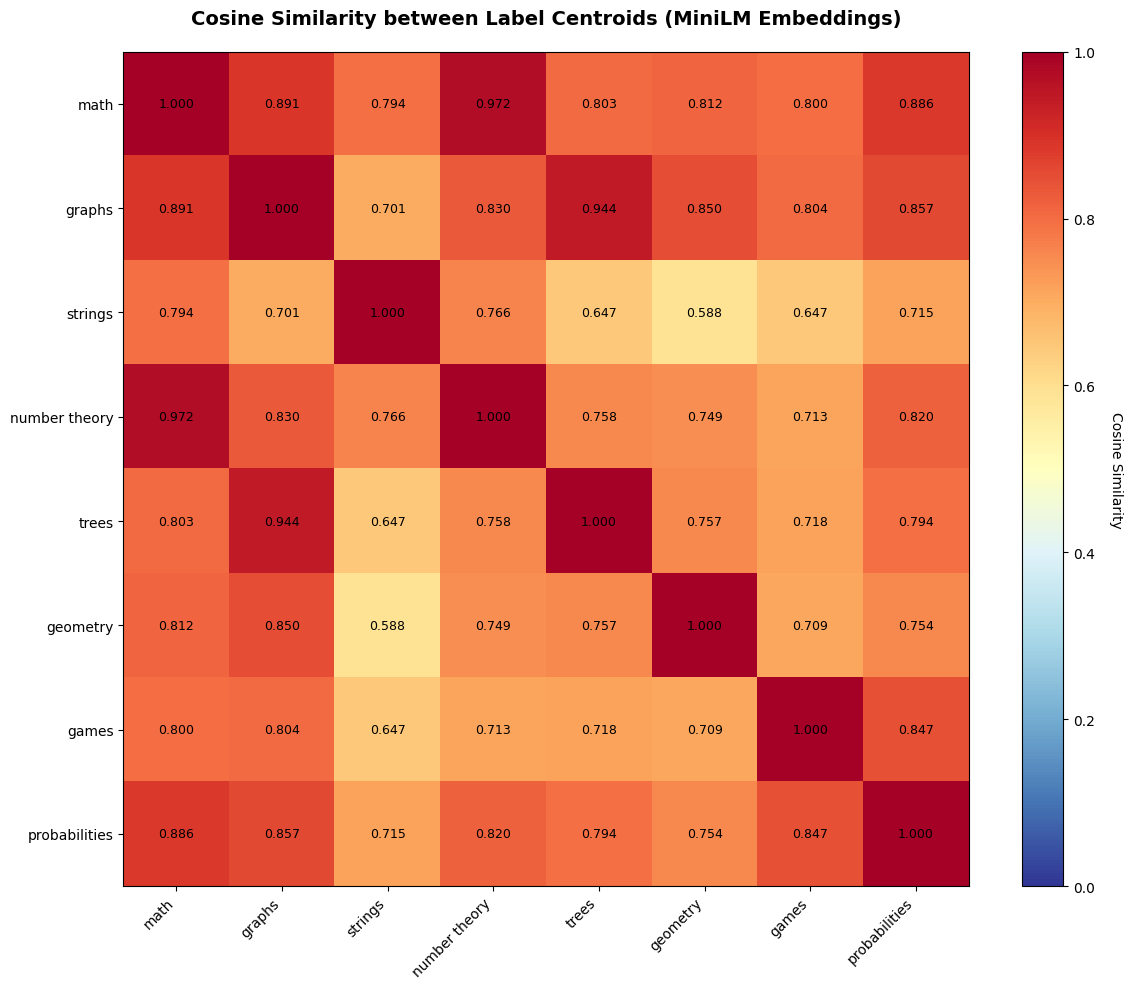

Heatmap sauvegardée: ../docs/embeddings/centroid_similarity_heatmap.png


In [17]:
# Heatmap
fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(centroid_sim_matrix, cmap='RdYlBu_r', vmin=0, vmax=1, aspect='auto')

# Ticks
ax.set_xticks(np.arange(len(PRIORITY_TAGS)))
ax.set_yticks(np.arange(len(PRIORITY_TAGS)))
ax.set_xticklabels(PRIORITY_TAGS, rotation=45, ha='right')
ax.set_yticklabels(PRIORITY_TAGS)

# Annotations
for i in range(len(PRIORITY_TAGS)):
    for j in range(len(PRIORITY_TAGS)):
        text = ax.text(j, i, f"{centroid_sim_matrix[i, j]:.3f}",
                      ha="center", va="center", color="black", fontsize=9)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Cosine Similarity', rotation=270, labelpad=20)

ax.set_title('Cosine Similarity between Label Centroids (MiniLM Embeddings)', 
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'centroid_similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Heatmap sauvegardée: {OUTPUTS_DIR / 'centroid_similarity_heatmap.png'}")


---
## 7.4 Distributions de Similarité Cosine (Positifs vs Négatifs)

Pour chaque tag, on analyse:
1. La distribution des similarités cosine entre chaque document et le centroid du tag
2. Comparaison entre documents positifs (label=1) et négatifs (label=0)

**Interprétation**:
- Si les positifs ont des similarités significativement plus élevées → bonne séparation
- Si les distributions se chevauchent beaucoup → difficulté à distinguer


In [18]:
def plot_similarity_distribution(tag: str, col: str, centroid: np.ndarray, 
                                 embeddings: np.ndarray, df: pd.DataFrame,
                                 output_dir: Path) -> Dict:
    """
    Plot la distribution de similarité cosine pour un tag.
    
    Parameters
    ----------
    tag : str
        Nom du tag
    col : str
        Nom de la colonne label
    centroid : np.ndarray
        Vecteur centroid du tag
    embeddings : np.ndarray
        Matrice d'embeddings
    df : pd.DataFrame
        DataFrame avec les labels
    output_dir : Path
        Répertoire de sortie
        
    Returns
    -------
    dict
        Statistiques de séparation
    """
    # Calcul des similarités (dot product car normalisés)
    similarities = embeddings @ centroid
    
    # Séparation positifs/négatifs
    pos_mask = df[col] == 1
    neg_mask = df[col] == 0
    
    sim_pos = similarities[pos_mask]
    sim_neg = similarities[neg_mask]
    
    # Statistiques
    stats = {
        'tag': tag,
        'n_pos': len(sim_pos),
        'n_neg': len(sim_neg),
        'mean_pos': sim_pos.mean(),
        'mean_neg': sim_neg.mean(),
        'median_pos': np.median(sim_pos),
        'median_neg': np.median(sim_neg),
        'std_pos': sim_pos.std(),
        'std_neg': sim_neg.std(),
        'delta_mean': sim_pos.mean() - sim_neg.mean(),
    }
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 6))
    
    bins = np.linspace(similarities.min(), similarities.max(), 50)
    
    ax.hist(sim_neg, bins=bins, alpha=0.6, label=f'Négatifs (n={len(sim_neg)})', 
            color='steelblue', density=True)
    ax.hist(sim_pos, bins=bins, alpha=0.6, label=f'Positifs (n={len(sim_pos)})', 
            color='coral', density=True)
    
    # Lignes de moyennes
    ax.axvline(stats['mean_neg'], color='steelblue', linestyle='--', linewidth=2, 
               label=f"Moyenne neg: {stats['mean_neg']:.3f}")
    ax.axvline(stats['mean_pos'], color='coral', linestyle='--', linewidth=2,
               label=f"Moyenne pos: {stats['mean_pos']:.3f}")
    
    ax.set_xlabel('Cosine Similarity avec Centroid', fontsize=12)
    ax.set_ylabel('Densité', fontsize=12)
    ax.set_title(f"Distribution Similarité: {tag}\n"
                f"Δmean = {stats['delta_mean']:.3f}", 
                fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Sauvegarde
    slug = slugify_tag(tag)
    output_path = output_dir / f'dist_similarity_{slug}.png'
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.close()
    
    return stats

# Application pour tous les tags
print("Génération des distributions de similarité...")
print("="*80)

all_stats = []

for tag, col in zip(PRIORITY_TAGS, label_columns):
    centroid = centroids[tag]
    stats = plot_similarity_distribution(
        tag=tag,
        col=col,
        centroid=centroid,
        embeddings=embeddings,
        df=df,
        output_dir=OUTPUTS_DIR
    )
    all_stats.append(stats)
    
    print(f"✓ {tag:20s}: Δmean={stats['delta_mean']:.4f}, "
          f"mean_pos={stats['mean_pos']:.3f}, mean_neg={stats['mean_neg']:.3f}")

print("="*80)

# Résumé sous forme de DataFrame
stats_df = pd.DataFrame(all_stats)
print("\nRésumé des statistiques:")
print(stats_df[['tag', 'n_pos', 'delta_mean', 'mean_pos', 'mean_neg']].to_string(index=False))

# Tags avec meilleure/pire séparation
stats_df_sorted = stats_df.sort_values('delta_mean', ascending=False)
print("\nTags avec meilleure séparation (Δmean élevé):")
print(stats_df_sorted[['tag', 'delta_mean']].head(3).to_string(index=False))

print("\nTags avec pire séparation (Δmean faible):")
print(stats_df_sorted[['tag', 'delta_mean']].tail(3).to_string(index=False))


Génération des distributions de similarité...
✓ math                : Δmean=0.0583, mean_pos=0.570, mean_neg=0.512
✓ graphs              : Δmean=0.0496, mean_pos=0.546, mean_neg=0.496
✓ strings             : Δmean=0.1909, mean_pos=0.618, mean_neg=0.427
✓ number theory       : Δmean=0.1225, mean_pos=0.617, mean_neg=0.495
✓ trees               : Δmean=0.1543, mean_pos=0.602, mean_neg=0.448
✓ geometry            : Δmean=0.1052, mean_pos=0.553, mean_neg=0.448
✓ games               : Δmean=0.2473, mean_pos=0.690, mean_neg=0.443
✓ probabilities       : Δmean=0.0514, mean_pos=0.537, mean_neg=0.486

Résumé des statistiques:
          tag  n_pos  delta_mean  mean_pos  mean_neg
         math   1127    0.058277  0.570426  0.512148
       graphs    444    0.049593  0.545526  0.495932
      strings    342    0.190886  0.618189  0.427303
number theory    285    0.122470  0.617334  0.494864
        trees    255    0.154254  0.602115  0.447860
     geometry    128    0.105223  0.552958  0.447734
     

In [19]:
def show_top_documents(tag: str, col: str, centroid: np.ndarray, 
                       embeddings: np.ndarray, df: pd.DataFrame, n: int = 5):
    """
    Affiche les top documents pour un tag.
    """
    # Calcul des similarités
    similarities = embeddings @ centroid
    
    # Masques
    pos_mask = df[col] == 1
    neg_mask = df[col] == 0
    
    print(f"\n{'='*80}")
    print(f"TAG: {tag.upper()}")
    print(f"{'='*80}")
    
    # Top positifs
    print(f"\n🎯 Top {n} Positifs (plus similaires au centroid):")
    print("-"*80)
    
    pos_indices = df[pos_mask].index
    pos_sims = similarities[pos_mask]
    top_pos_idx = pos_indices[np.argsort(pos_sims)[-n:][::-1]]
    
    for rank, idx in enumerate(top_pos_idx, 1):
        sim = similarities[idx]
        text = df.loc[idx, 'unified_document_trunc'][:150]
        tags = df.loc[idx, 'tags']
        print(f"\n{rank}. Similarité: {sim:.4f}")
        print(f"   Tags: {tags}")
        print(f"   Texte: {text}...")
    
    # Hard negatives
    print(f"\n⚠️  Top {n} Hard Negatives (négatifs similaires au centroid):")
    print("-"*80)
    
    neg_indices = df[neg_mask].index
    neg_sims = similarities[neg_mask]
    
    if len(neg_sims) > 0:
        top_neg_idx = neg_indices[np.argsort(neg_sims)[-n:][::-1]]
        
        for rank, idx in enumerate(top_neg_idx, 1):
            sim = similarities[idx]
            text = df.loc[idx, 'unified_document_trunc'][:150]
            tags = df.loc[idx, 'tags']
            print(f"\n{rank}. Similarité: {sim:.4f}")
            print(f"   Tags: {tags}")
            print(f"   Texte: {text}...")
    else:
        print("Aucun document négatif.")

# Sélection de 2-3 tags à analyser
tags_to_analyze = ['probabilities', 'number theory', 'games']

for tag in tags_to_analyze:
    if tag not in PRIORITY_TAGS:
        continue
    
    idx = PRIORITY_TAGS.index(tag)
    col = label_columns[idx]
    centroid = centroids[tag]
    
    show_top_documents(tag, col, centroid, embeddings, df, n=5)



TAG: PROBABILITIES

🎯 Top 5 Positifs (plus similaires au centroid):
--------------------------------------------------------------------------------

1. Similarité: 0.6859
   Tags: ['bitmasks' 'combinatorics' 'dp' 'graphs' 'math' 'probabilities']
   Texte: [desc] william is not only interested in trading but also in betting on sports matches. mathblock teams participate in each match. each team is charac...

2. Similarité: 0.6730
   Tags: ['dp' 'probabilities' 'math']
   Texte: [desc] let mathblock be an array of integers mathblock . let's define mathblock as a minimal size of a partition of mathblock into subsegments such th...

3. Similarité: 0.6662
   Tags: ['probabilities' 'math']
   Texte: [desc] slime and his mathblock friends are at a party. slime has designed a game for his friends to play.at the beginning of the game, the mathblock -...

4. Similarité: 0.6557
   Tags: ['dp' 'combinatorics' 'probabilities']
   Texte: [desc] an online contest will soon be held on forcecoders, a

---
## 9. Résumé Final

**Livrables créés**:
1. ✅ `embeddings`: matrice (n_docs, 384) normalisée L2
2. ✅ `centroids`: dict {tag: vecteur centroid} pour 8 tags prioritaires
3. ✅ `centroid_sim_matrix`: matrice 8x8 de similarité cosine entre centroids
4. ✅ Figures sauvegardées dans `docs/embeddings/`:
   - Heatmap de similarité entre centroids
   - 8 distributions de similarité (positifs vs négatifs)

**Variables disponibles pour la suite**:
- `df`: DataFrame avec colonnes `unified_document_clean`, `unified_document_trunc`, 8 labels binaires
- `embeddings`: numpy array (n_docs, 384)
- `centroids`: dict
- `centroid_sim_matrix`: numpy array (8, 8)
- `label_columns`: liste des noms de colonnes labels

**Prochaines étapes possibles**:
1. Modélisation avec embeddings (notebook 07)
2. Réduction dimensionnelle (UMAP/t-SNE) pour visualisation
3. Clustering et analyse d'outliers
4. Approche hybride: combinaison TF-IDF + Embeddings


In [20]:
print("\n" + "="*80)
print("RÉSUMÉ FINAL")
print("="*80)

print(f"\n📊 Dataset:")
print(f"   Nombre de documents: {len(df)}")
print(f"   Colonnes créées: {len(label_columns)} labels binaires")

print(f"\n🔢 Embeddings:")
print(f"   Shape: {embeddings.shape}")
print(f"   Dtype: {embeddings.dtype}")
print(f"   Normalisés L2: Oui")
print(f"   Sauvegardés: {DATA_DIR / 'embeddings_minilm_train.npy'}")

print(f"\n🎯 Centroids:")
print(f"   Nombre de centroids: {len(centroids)}")
print(f"   Tags: {list(centroids.keys())}")

print(f"\n📈 Similarités entre centroids:")
print(f"   Min (hors diag): {off_diag.min():.4f}")
print(f"   Mean (hors diag): {off_diag.mean():.4f}")
print(f"   Max (hors diag): {off_diag.max():.4f}")

print(f"\n📊 Séparation positifs/négatifs:")
print(f"   Meilleur Δmean: {stats_df_sorted.iloc[0]['tag']} ({stats_df_sorted.iloc[0]['delta_mean']:.4f})")
print(f"   Pire Δmean: {stats_df_sorted.iloc[-1]['tag']} ({stats_df_sorted.iloc[-1]['delta_mean']:.4f})")

print(f"\n💾 Figures sauvegardées:")
figures = list(OUTPUTS_DIR.glob('*.png'))
print(f"   Répertoire: {OUTPUTS_DIR}")
print(f"   Nombre de figures: {len(figures)}")
for fig in figures:
    print(f"   - {fig.name}")

print("\n" + "="*80)
print("✅ Notebook 06 - Embeddings V1: TERMINÉ")
print("="*80)



RÉSUMÉ FINAL

📊 Dataset:
   Nombre de documents: 3979
   Colonnes créées: 8 labels binaires

🔢 Embeddings:
   Shape: (3979, 384)
   Dtype: float32
   Normalisés L2: Oui
   Sauvegardés: ../data/processed/embeddings_minilm_train.npy

🎯 Centroids:
   Nombre de centroids: 8
   Tags: ['math', 'graphs', 'strings', 'number theory', 'trees', 'geometry', 'games', 'probabilities']

📈 Similarités entre centroids:
   Min (hors diag): 0.5876
   Mean (hors diag): 0.7830
   Max (hors diag): 0.9723

📊 Séparation positifs/négatifs:
   Meilleur Δmean: games (0.2473)
   Pire Δmean: graphs (0.0496)

💾 Figures sauvegardées:
   Répertoire: ../docs/embeddings
   Nombre de figures: 9
   - centroid_similarity_heatmap.png
   - dist_similarity_games.png
   - dist_similarity_geometry.png
   - dist_similarity_graphs.png
   - dist_similarity_math.png
   - dist_similarity_number_theory.png
   - dist_similarity_probabilities.png
   - dist_similarity_strings.png
   - dist_similarity_trees.png

✅ Notebook 06 - Embeddi

---
## 10. Fonction d'Évaluation Rapide d'Embedders

Cette section fournit une fonction réutilisable pour tester rapidement différents modèles d'embeddings sur le même dataset.


In [ ]:
def evaluate_embedder(
    model_name: str,
    df: pd.DataFrame,
    text_column: str,
    target_columns: List[str],
    priority_tags: List[str],
    output_prefix: str,
    max_words: int = 400,
    batch_size: int = 64,
    output_dir: Path = OUTPUTS_DIR,
    data_dir: Path = DATA_DIR,
    verbose: bool = True,
    replace_latex: bool = True
) -> Dict:
    """
    Évalue rapidement un modèle d'embeddings sur le dataset.
    
    Cette fonction permet de tester différents embedders et de comparer
    leurs performances en termes de séparation des classes.
    
    Parameters
    ----------
    model_name : str
        Nom du modèle Sentence-Transformers (ex: 'all-mpnet-base-v2')
    df : pd.DataFrame
        DataFrame contenant les données
    text_column : str
        Nom de la colonne contenant le texte à embedder
    target_columns : list of str
        Liste des colonnes target (ex: ['target_math', 'target_graphs', ...])
    priority_tags : list of str
        Liste des tags prioritaires (ex: ['math', 'graphs', ...])
    output_prefix : str
        Préfixe pour les fichiers de sortie (ex: 'mpnet', 'minilm')
    max_words : int, default=400
        Nombre maximum de mots à conserver
    batch_size : int, default=64
        Taille des batchs pour l'encoding
    output_dir : Path, default=OUTPUTS_DIR
        Répertoire pour sauvegarder les figures
    data_dir : Path, default=DATA_DIR
        Répertoire pour sauvegarder les embeddings
    verbose : bool, default=True
        Afficher les informations de progression
    replace_latex : bool, default=True
        Si True, remplace le LaTeX par des tokens (MATHBLOCK, LATEX_GCD, etc.)
        Si False, garde le LaTeX brut (utile pour SPECTER)
        
    Returns
    -------
    dict
        Dictionnaire contenant:
        - 'embeddings': numpy array (n_docs, n_dims)
        - 'centroids': dict {tag: centroid}
        - 'centroid_sim_matrix': matrice de similarité (n_tags, n_tags)
        - 'stats': DataFrame avec statistiques par tag (delta_mean, etc.)
        - 'model_name': nom du modèle
        - 'embedding_dim': dimension des embeddings
    
    Examples
    --------
    >>> results = evaluate_embedder(
    ...     model_name='all-mpnet-base-v2',
    ...     df=df,
    ...     text_column='unified_document_clean',
    ...     target_columns=label_columns,
    ...     priority_tags=PRIORITY_TAGS,
    ...     output_prefix='mpnet'
    ... )
    >>> print(f"Meilleur tag: {results['stats'].iloc[0]['tag']} (Δmean={results['stats'].iloc[0]['delta_mean']:.3f})")
    """
    
    if verbose:
        print("\n" + "="*80)
        print(f"ÉVALUATION EMBEDDER: {model_name}")
        print("="*80)
    
    # 1. Vérifications
    assert text_column in df.columns, f"Colonne '{text_column}' non trouvée"
    assert len(target_columns) == len(priority_tags), "Nombre de target_columns != priority_tags"
    
    # 2. Preprocessing du texte (si pas déjà fait)
    if verbose:
        print(f"\n[1/7] Preprocessing du texte...")
    
    # On nettoie le texte
    texts_clean = df[text_column].apply(lambda x: clean_text_for_embeddings(x, replace_latex=replace_latex))
    
    # Troncature
    texts_trunc = texts_clean.apply(lambda x: truncate_text(x, max_words=max_words))
    texts = texts_trunc.fillna("").tolist()
    
    n_truncated = (texts_clean.apply(lambda x: len(x.split())) > max_words).sum()
    if verbose:
        print(f"   Documents tronqués: {n_truncated} / {len(df)} ({n_truncated/len(df)*100:.1f}%)")
    
    # 3. Chargement du modèle
    if verbose:
        print(f"\n[2/7] Chargement du modèle '{model_name}'...")
    
    try:
        model = SentenceTransformer(model_name)
        embedding_dim = model.get_sentence_embedding_dimension()
        if verbose:
            print(f"   Modèle chargé: {embedding_dim} dimensions")
    except Exception as e:
        print(f"❌ Erreur lors du chargement du modèle: {e}")
        raise
    
    # 4. Calcul des embeddings
    if verbose:
        print(f"\n[3/7] Encoding de {len(texts)} documents...")
    
    embeddings = model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=verbose,
        convert_to_numpy=True,
        normalize_embeddings=True
    )
    
    if verbose:
        print(f"   Shape: {embeddings.shape}")
        print(f"   Memory: {embeddings.nbytes / 1024**2:.2f} MB")
    
    # 5. Calcul des centroids
    if verbose:
        print(f"\n[4/7] Calcul des centroids...")
    
    centroids = {}
    for tag, col in zip(priority_tags, target_columns):
        pos_idx = df[col] == 1
        n_pos = pos_idx.sum()
        
        if n_pos == 0:
            centroids[tag] = np.zeros(embedding_dim)
            continue
        
        centroid = embeddings[pos_idx].mean(axis=0)
        centroid_norm = np.linalg.norm(centroid)
        if centroid_norm > 0:
            centroid = centroid / centroid_norm
        
        centroids[tag] = centroid
    
    # 6. Matrice de similarité entre centroids
    if verbose:
        print(f"\n[5/7] Calcul de la matrice de similarité...")
    
    centroid_matrix = np.array([centroids[tag] for tag in priority_tags])
    centroid_sim_matrix = cosine_similarity(centroid_matrix)
    
    # Affichage
    centroid_sim_df = pd.DataFrame(
        centroid_sim_matrix,
        index=priority_tags,
        columns=priority_tags
    )
    
    if verbose:
        print("\nMatrice de similarité cosine entre centroids:")
        print(centroid_sim_df.round(3))
        
        off_diag = centroid_sim_matrix[~np.eye(len(priority_tags), dtype=bool)]
        print(f"\nStatistiques (hors diagonale):")
        print(f"  Min:    {off_diag.min():.4f}")
        print(f"  Mean:   {off_diag.mean():.4f}")
        print(f"  Median: {np.median(off_diag):.4f}")
        print(f"  Max:    {off_diag.max():.4f}")
    
    # Heatmap
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(centroid_sim_matrix, cmap='RdYlBu_r', vmin=0, vmax=1, aspect='auto')
    
    ax.set_xticks(np.arange(len(priority_tags)))
    ax.set_yticks(np.arange(len(priority_tags)))
    ax.set_xticklabels(priority_tags, rotation=45, ha='right')
    ax.set_yticklabels(priority_tags)
    
    for i in range(len(priority_tags)):
        for j in range(len(priority_tags)):
            ax.text(j, i, f"{centroid_sim_matrix[i, j]:.3f}",
                   ha="center", va="center", color="black", fontsize=9)
    
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Cosine Similarity', rotation=270, labelpad=20)
    
    ax.set_title(f'Centroid Similarity: {model_name}', 
                 fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    heatmap_path = output_dir / f'{output_prefix}_centroid_similarity.png'
    plt.savefig(heatmap_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    if verbose:
        print(f"\nHeatmap sauvegardée: {heatmap_path}")
    
    # 7. Distributions de similarité (positifs vs négatifs)
    if verbose:
        print(f"\n[6/7] Calcul des distributions de similarité...")
    
    all_stats = []
    
    for tag, col in zip(priority_tags, target_columns):
        centroid = centroids[tag]
        similarities = embeddings @ centroid
        
        pos_mask = df[col] == 1
        neg_mask = df[col] == 0
        
        sim_pos = similarities[pos_mask]
        sim_neg = similarities[neg_mask]
        
        stats = {
            'tag': tag,
            'n_pos': len(sim_pos),
            'n_neg': len(sim_neg),
            'mean_pos': sim_pos.mean(),
            'mean_neg': sim_neg.mean(),
            'median_pos': np.median(sim_pos),
            'median_neg': np.median(sim_neg),
            'std_pos': sim_pos.std(),
            'std_neg': sim_neg.std(),
            'delta_mean': sim_pos.mean() - sim_neg.mean(),
        }
        all_stats.append(stats)
        
        # Plot
        fig, ax = plt.subplots(figsize=(12, 6))
        bins = np.linspace(similarities.min(), similarities.max(), 50)
        
        ax.hist(sim_neg, bins=bins, alpha=0.6, label=f'Négatifs (n={len(sim_neg)})', 
                color='steelblue', density=True)
        ax.hist(sim_pos, bins=bins, alpha=0.6, label=f'Positifs (n={len(sim_pos)})', 
                color='coral', density=True)
        
        ax.axvline(stats['mean_neg'], color='steelblue', linestyle='--', linewidth=2, 
                   label=f"Moyenne neg: {stats['mean_neg']:.3f}")
        ax.axvline(stats['mean_pos'], color='coral', linestyle='--', linewidth=2,
                   label=f"Moyenne pos: {stats['mean_pos']:.3f}")
        
        ax.set_xlabel('Cosine Similarity', fontsize=12)
        ax.set_ylabel('Densité', fontsize=12)
        ax.set_title(f"{model_name} - {tag}\nΔmean = {stats['delta_mean']:.3f}", 
                    fontsize=14, fontweight='bold')
        ax.legend(loc='upper left', fontsize=10)
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        slug = slugify_tag(tag)
        dist_path = output_dir / f'{output_prefix}_dist_{slug}.png'
        plt.savefig(dist_path, dpi=150, bbox_inches='tight')
        plt.close()
    
    stats_df = pd.DataFrame(all_stats)
    stats_df_sorted = stats_df.sort_values('delta_mean', ascending=False)
    
    if verbose:
        print("\nRésumé des statistiques:")
        print(stats_df_sorted[['tag', 'n_pos', 'delta_mean', 'mean_pos', 'mean_neg']].to_string(index=False))
        
        print(f"\n✅ Meilleure séparation: {stats_df_sorted.iloc[0]['tag']} (Δmean={stats_df_sorted.iloc[0]['delta_mean']:.4f})")
        print(f"❌ Pire séparation: {stats_df_sorted.iloc[-1]['tag']} (Δmean={stats_df_sorted.iloc[-1]['delta_mean']:.4f})")
        print(f"📊 Moyenne Δmean: {stats_df['delta_mean'].mean():.4f}")
    
    # 8. Sauvegarde des embeddings
    if verbose:
        print(f"\n[7/7] Sauvegarde des embeddings...")
    
    embeddings_path = data_dir / f'{output_prefix}_embeddings_train.npy'
    np.save(embeddings_path, embeddings)
    
    if verbose:
        print(f"   Embeddings: {embeddings_path}")
        print(f"   Figures: {output_dir / f'{output_prefix}_*.png'}")
    
    # Résultat final
    results = {
        'model_name': model_name,
        'embedding_dim': embedding_dim,
        'embeddings': embeddings,
        'centroids': centroids,
        'centroid_sim_matrix': centroid_sim_matrix,
        'stats': stats_df_sorted,
        'mean_delta_mean': stats_df['delta_mean'].mean(),
        'centroid_sim_mean': off_diag.mean(),
    }
    
    if verbose:
        print("\n" + "="*80)
        print("✅ ÉVALUATION TERMINÉE")
        print("="*80)
    
    return results


### Exemple d'utilisation : Comparer plusieurs embedders

Décommentez le code ci-dessous pour tester différents modèles :

```python
# Liste de modèles à tester
models_to_test = [
    ('sentence-transformers/all-MiniLM-L6-v2', 'minilm'),  # Baseline (déjà fait)
    ('sentence-transformers/all-mpnet-base-v2', 'mpnet'),  # Meilleur modèle général
    ('sentence-transformers/allenai-specter', 'specter'),  # Spécialisé scientifique
]

# Comparer les résultats
comparison = []

for model_name, prefix in models_to_test:
    print(f"\n{'='*80}")
    print(f"TEST: {model_name}")
    print(f"{'='*80}")
    
    try:
        results = evaluate_embedder(
            model_name=model_name,
            df=df,
            text_column='unified_document_clean',
            target_columns=label_columns,
            priority_tags=PRIORITY_TAGS,
            output_prefix=prefix,
            max_words=400,
            batch_size=64,
            verbose=True
        )
        
        comparison.append({
            'model': model_name,
            'prefix': prefix,
            'embedding_dim': results['embedding_dim'],
            'mean_delta_mean': results['mean_delta_mean'],
            'centroid_sim_mean': results['centroid_sim_mean'],
            'best_tag': results['stats'].iloc[0]['tag'],
            'best_delta_mean': results['stats'].iloc[0]['delta_mean'],
            'worst_tag': results['stats'].iloc[-1]['tag'],
            'worst_delta_mean': results['stats'].iloc[-1]['delta_mean'],
        })
        
    except Exception as e:
        print(f"❌ Erreur avec {model_name}: {e}")
        continue

# Comparaison finale
comparison_df = pd.DataFrame(comparison)
print("\n" + "="*80)
print("COMPARAISON DES MODÈLES")
print("="*80)
print(comparison_df.to_string(index=False))

# Meilleur modèle selon mean_delta_mean
best_model = comparison_df.loc[comparison_df['mean_delta_mean'].idxmax()]
print(f"\n🏆 Meilleur modèle: {best_model['model']}")
print(f"   Mean Δmean: {best_model['mean_delta_mean']:.4f}")
print(f"   Meilleur tag: {best_model['best_tag']} (Δmean={best_model['best_delta_mean']:.4f})")
```


### 10.1 Test sur description uniquement


ÉVALUATION EMBEDDER: sentence-transformers/all-MiniLM-L6-v2

[1/7] Preprocessing du texte...
   Documents tronqués: 55 / 3979 (1.4%)

[2/7] Chargement du modèle 'sentence-transformers/all-MiniLM-L6-v2'...
   Modèle chargé: 384 dimensions

[3/7] Encoding de 3979 documents...


Batches: 100%|██████████| 125/125 [03:25<00:00,  1.64s/it]


   Shape: (3979, 384)
   Memory: 5.83 MB

[4/7] Calcul des centroids...

[5/7] Calcul de la matrice de similarité...

Matrice de similarité cosine entre centroids:
                math  graphs  strings  number theory  trees  geometry  games  \
math           1.000   0.863    0.734          0.959  0.765     0.740  0.755   
graphs         0.863   1.000    0.640          0.779  0.931     0.794  0.760   
strings        0.734   0.640    1.000          0.681  0.594     0.479  0.571   
number theory  0.959   0.779    0.681          1.000  0.703     0.652  0.644   
trees          0.765   0.931    0.594          0.703  1.000     0.687  0.661   
geometry       0.740   0.794    0.479          0.652  0.687     1.000  0.636   
games          0.755   0.760    0.571          0.644  0.661     0.636  1.000   
probabilities  0.847   0.817    0.656          0.749  0.746     0.665  0.806   

               probabilities  
math                   0.847  
graphs                 0.817  
strings               

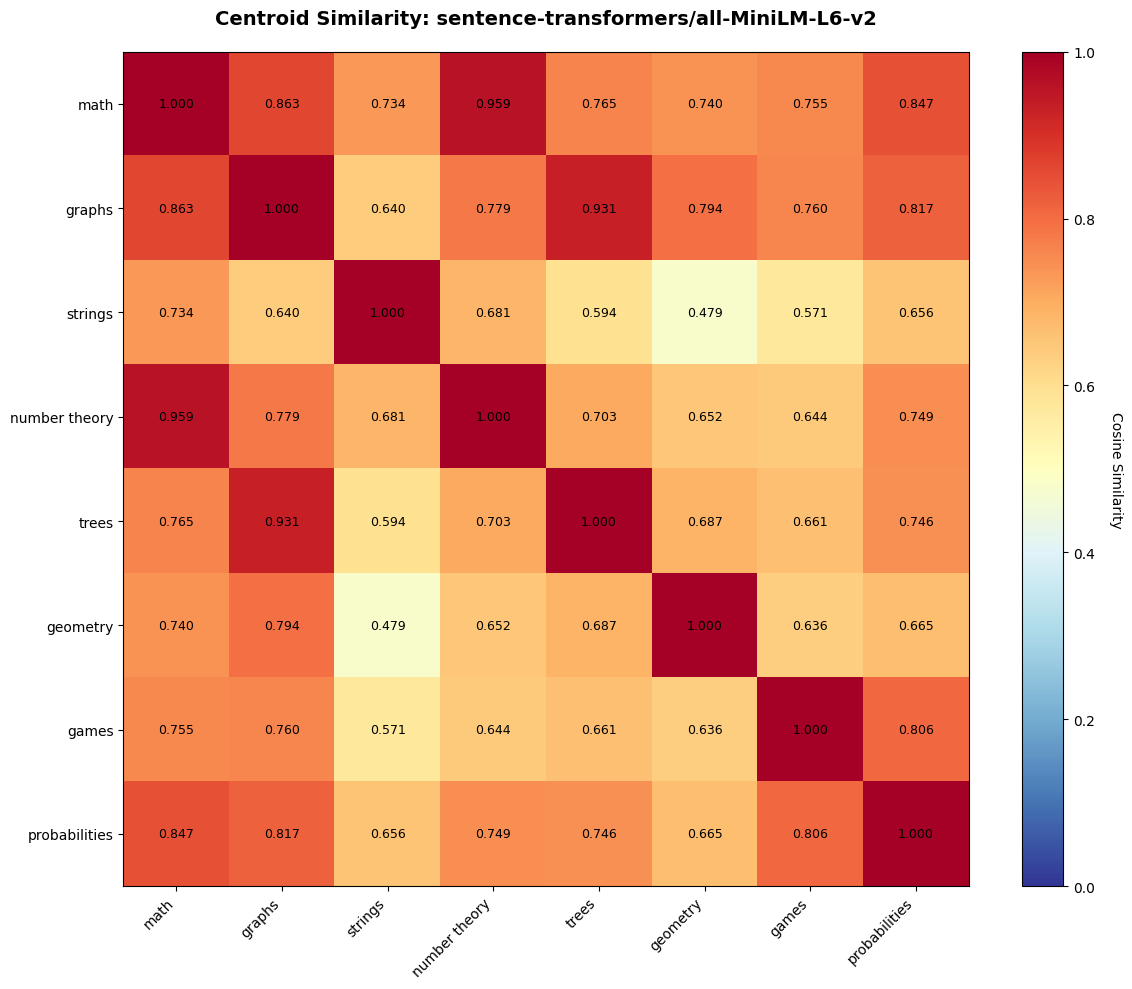


Heatmap sauvegardée: ../docs/embeddings/all-MiniLM-L6-v2_desc_only_centroid_similarity.png

[6/7] Calcul des distributions de similarité...

Résumé des statistiques:
          tag  n_pos  delta_mean  mean_pos  mean_neg
        games     87    0.300305  0.665069  0.364765
      strings    342    0.216464  0.561392  0.344928
        trees    255    0.178835  0.551512  0.372677
number theory    285    0.133787  0.546216  0.412429
     geometry    128    0.129379  0.485650  0.356271
probabilities     77    0.092105  0.498334  0.406229
       graphs    444    0.063325  0.483105  0.419779
         math   1127    0.061468  0.499113  0.437645

✅ Meilleure séparation: games (Δmean=0.3003)
❌ Pire séparation: math (Δmean=0.0615)
📊 Moyenne Δmean: 0.1470

[7/7] Sauvegarde des embeddings...
   Embeddings: ../data/processed/all-MiniLM-L6-v2_desc_only_embeddings_train.npy
   Figures: ../docs/embeddings/all-MiniLM-L6-v2_desc_only_*.png

✅ ÉVALUATION TERMINÉE

📊 Résumé mpnet:
   Mean Δmean: 0.1470
   C

In [28]:
# Exemple rapide: Tester un seul embedder
# Décommentez pour tester mpnet (meilleur modèle général de Sentence-Transformers)

col_interet = 'prob_desc_description'

results_MiniLM = evaluate_embedder(
    model_name='sentence-transformers/all-MiniLM-L6-v2',
    df=df,
    text_column=col_interet,
    target_columns=label_columns,
    priority_tags=PRIORITY_TAGS,
    output_prefix='all-MiniLM-L6-v2_desc_only',
    max_words=400,
    batch_size=32,  # Réduire si problème de mémoire
    verbose=True
)

print(f"\n📊 Résumé mpnet:")
print(f"   Mean Δmean: {results_MiniLM['mean_delta_mean']:.4f}")
print(f"   Centroid similarity mean: {results_MiniLM['centroid_sim_mean']:.4f}")
print(f"   Best tag: {results_MiniLM['stats'].iloc[0]['tag']} (Δmean={results_MiniLM['stats'].iloc[0]['delta_mean']:.4f})")



ÉVALUATION EMBEDDER: sentence-transformers/all-mpnet-base-v2

[1/7] Preprocessing du texte...
   Documents tronqués: 55 / 3979 (1.4%)

[2/7] Chargement du modèle 'sentence-transformers/all-mpnet-base-v2'...
   Modèle chargé: 768 dimensions

[3/7] Encoding de 3979 documents...


Batches: 100%|██████████| 125/125 [4:47:09<00:00, 137.84s/it]   


   Shape: (3979, 768)
   Memory: 11.66 MB

[4/7] Calcul des centroids...

[5/7] Calcul de la matrice de similarité...

Matrice de similarité cosine entre centroids:
                math  graphs  strings  number theory  trees  geometry  games  \
math           1.000   0.889    0.785          0.963  0.807     0.789  0.754   
graphs         0.889   1.000    0.724          0.805  0.939     0.817  0.749   
strings        0.785   0.724    1.000          0.725  0.681     0.596  0.614   
number theory  0.963   0.805    0.725          1.000  0.741     0.698  0.673   
trees          0.807   0.939    0.681          0.741  1.000     0.726  0.695   
geometry       0.789   0.817    0.596          0.698  0.726     1.000  0.643   
games          0.754   0.749    0.614          0.673  0.695     0.643  1.000   
probabilities  0.833   0.809    0.674          0.741  0.773     0.678  0.773   

               probabilities  
math                   0.833  
graphs                 0.809  
strings              

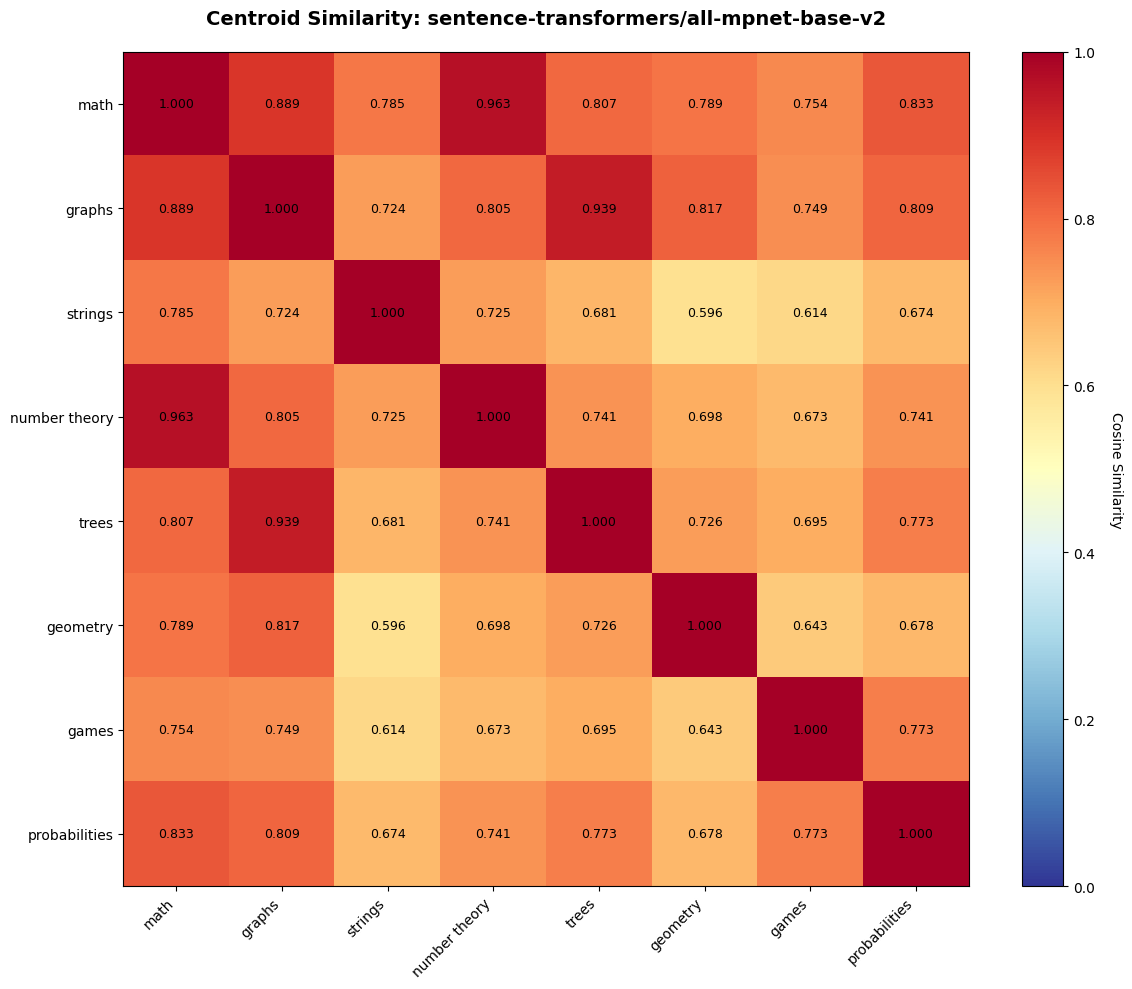


Heatmap sauvegardée: ../docs/embeddings/mpnet_desc_only_centroid_similarity.png

[6/7] Calcul des distributions de similarité...

Résumé des statistiques:
          tag  n_pos  delta_mean  mean_pos  mean_neg
        games     87    0.296101  0.705734  0.409633
      strings    342    0.188642  0.613102  0.424460
        trees    255    0.145850  0.592787  0.446937
     geometry    128    0.123107  0.554079  0.430972
number theory    285    0.106288  0.583851  0.477562
probabilities     77    0.097880  0.550428  0.452548
       graphs    444    0.059314  0.548436  0.489122
         math   1127    0.038238  0.548552  0.510314

✅ Meilleure séparation: games (Δmean=0.2961)
❌ Pire séparation: math (Δmean=0.0382)
📊 Moyenne Δmean: 0.1319

[7/7] Sauvegarde des embeddings...
   Embeddings: ../data/processed/mpnet_desc_only_embeddings_train.npy
   Figures: ../docs/embeddings/mpnet_desc_only_*.png

✅ ÉVALUATION TERMINÉE

📊 Résumé mpnet:
   Mean Δmean: 0.1319
   Centroid similarity mean: 0.7533
 

In [25]:
# Exemple rapide: Tester un seul embedder
# Décommentez pour tester mpnet (meilleur modèle général de Sentence-Transformers)

col_interet = 'prob_desc_description'

results_mpnet = evaluate_embedder(
    model_name='sentence-transformers/all-mpnet-base-v2',
    df=df,
    text_column=col_interet,
    target_columns=label_columns,
    priority_tags=PRIORITY_TAGS,
    output_prefix='mpnet_desc_only',
    max_words=400,
    batch_size=32,  # Réduire si problème de mémoire
    verbose=True
)

print(f"\n📊 Résumé mpnet:")
print(f"   Mean Δmean: {results_mpnet['mean_delta_mean']:.4f}")
print(f"   Centroid similarity mean: {results_mpnet['centroid_sim_mean']:.4f}")
print(f"   Best tag: {results_mpnet['stats'].iloc[0]['tag']} (Δmean={results_mpnet['stats'].iloc[0]['delta_mean']:.4f})")



ÉVALUATION EMBEDDER: sentence-transformers/allenai-specter

[1/7] Preprocessing du texte...
   Documents tronqués: 55 / 3979 (1.4%)

[2/7] Chargement du modèle 'sentence-transformers/allenai-specter'...
   Modèle chargé: 768 dimensions

[3/7] Encoding de 3979 documents...


Batches: 100%|██████████| 125/125 [30:47<00:00, 14.78s/it] 


   Shape: (3979, 768)
   Memory: 11.66 MB

[4/7] Calcul des centroids...

[5/7] Calcul de la matrice de similarité...

Matrice de similarité cosine entre centroids:
                math  graphs  strings  number theory  trees  geometry  games  \
math           1.000   0.981    0.975          0.996  0.974     0.970  0.951   
graphs         0.981   1.000    0.954          0.967  0.994     0.982  0.953   
strings        0.975   0.954    1.000          0.970  0.954     0.937  0.925   
number theory  0.996   0.967    0.970          1.000  0.964     0.951  0.934   
trees          0.974   0.994    0.954          0.964  1.000     0.972  0.947   
geometry       0.970   0.982    0.937          0.951  0.972     1.000  0.942   
games          0.951   0.953    0.925          0.934  0.947     0.942  1.000   
probabilities  0.987   0.985    0.963          0.976  0.980     0.974  0.972   

               probabilities  
math                   0.987  
graphs                 0.985  
strings              

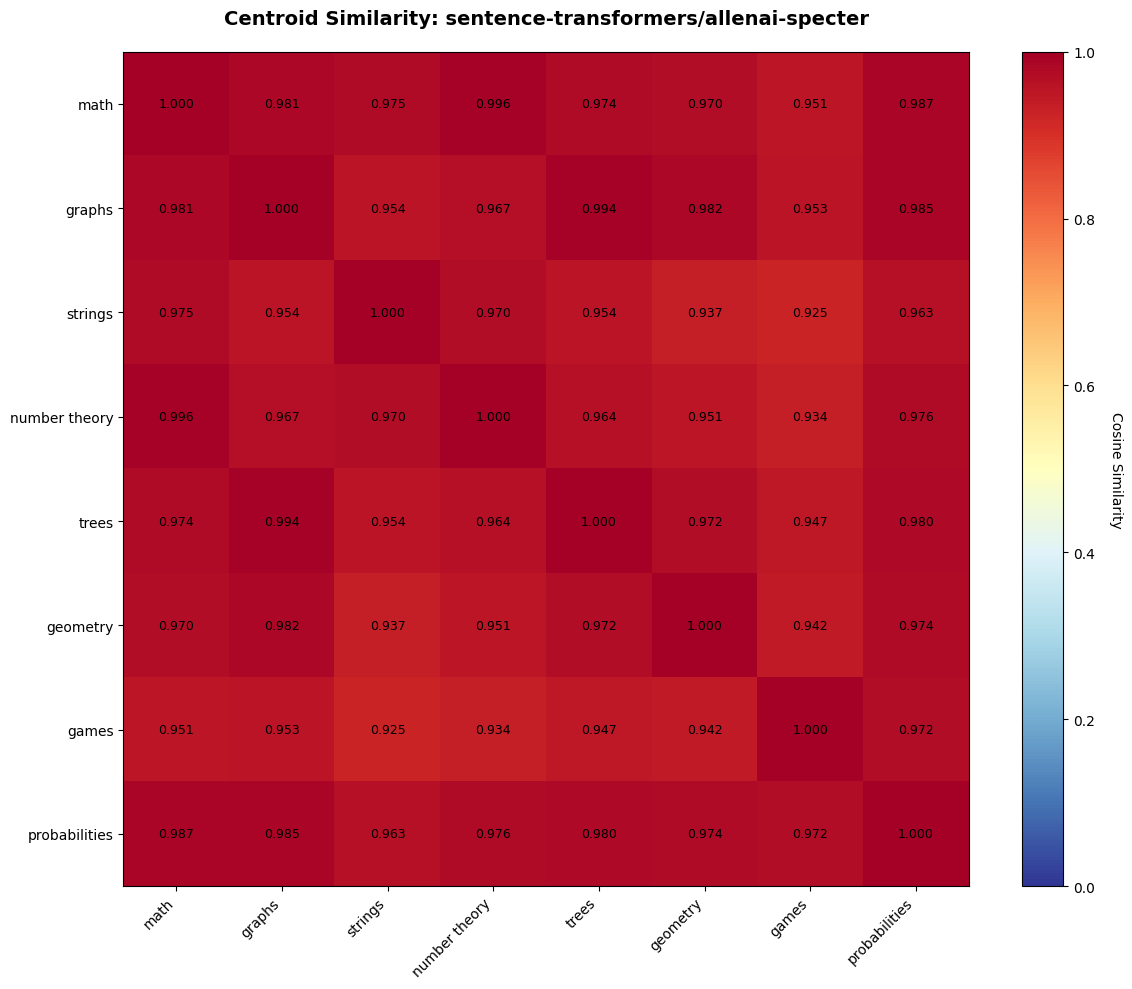


Heatmap sauvegardée: ../docs/embeddings/specter_desc_only_centroid_similarity.png

[6/7] Calcul des distributions de similarité...

Résumé des statistiques:
          tag  n_pos  delta_mean  mean_pos  mean_neg
        games     87    0.085755  0.898937  0.813182
      strings    342    0.054892  0.881579  0.826687
        trees    255    0.044003  0.877291  0.833288
number theory    285    0.040962  0.879337  0.838375
     geometry    128    0.025856  0.857844  0.831989
         math   1127    0.017696  0.861255  0.843558
       graphs    444    0.016877  0.856001  0.839124
probabilities     77    0.011390  0.855362  0.843973

✅ Meilleure séparation: games (Δmean=0.0858)
❌ Pire séparation: probabilities (Δmean=0.0114)
📊 Moyenne Δmean: 0.0372

[7/7] Sauvegarde des embeddings...
   Embeddings: ../data/processed/specter_desc_only_embeddings_train.npy
   Figures: ../docs/embeddings/specter_desc_only_*.png

✅ ÉVALUATION TERMINÉE

📊 Résumé mpnet:
   Mean Δmean: 0.0372
   Centroid similarity

In [26]:
col_interet = 'prob_desc_description'

results_mpnet = evaluate_embedder(
    model_name='sentence-transformers/allenai-specter',
    df=df,
    text_column=col_interet,
    target_columns=label_columns,
    priority_tags=PRIORITY_TAGS,
    output_prefix='specter_desc_only',
    max_words=400,
    batch_size=32,  # Réduire si problème de mémoire
    verbose=True
)

print(f"\n📊 Résumé mpnet:")
print(f"   Mean Δmean: {results_mpnet['mean_delta_mean']:.4f}")
print(f"   Centroid similarity mean: {results_mpnet['centroid_sim_mean']:.4f}")
print(f"   Best tag: {results_mpnet['stats'].iloc[0]['tag']} (Δmean={results_mpnet['stats'].iloc[0]['delta_mean']:.4f})")


### 📋 Modèles d'Embeddings Recommandés à Tester

Voici une liste de modèles Sentence-Transformers pertinents pour ce dataset :

#### **1. Modèles Généraux (Performance optimale)**
- `sentence-transformers/all-mpnet-base-v2` ✅ **RECOMMANDÉ**
  - 768 dimensions, meilleur modèle général de Sentence-Transformers
  - Excellent compromis performance/qualité
  - Attendu: Δmean plus élevé que MiniLM

- `sentence-transformers/all-MiniLM-L12-v2`
  - 384 dimensions, version plus puissante de MiniLM-L6
  - Plus lent mais potentiellement meilleure séparation

#### **2. Modèles Spécialisés Scientifiques**
- `sentence-transformers/allenai-specter` 🔬
  - 768 dimensions, entraîné sur des papers scientifiques
  - Peut mieux capturer les concepts mathématiques/algorithmiques
  - **À tester en priorité** pour ce use case

- `sentence-transformers/multi-qa-mpnet-base-dot-v1`
  - 768 dimensions, optimisé pour Q&A et recherche sémantique
  - Peut être pertinent pour les descriptions de problèmes

#### **3. Modèles Multi-lingues** (si dataset multilingue)
- `sentence-transformers/paraphrase-multilingual-mpnet-base-v2`
  - 768 dimensions, supporte 50+ langues
  - Utile si le dataset contient du texte non-anglais

#### **4. Critères de Sélection**

| Critère | Objectif | Comment mesurer |
|---------|----------|-----------------|
| **Mean Δmean** | > 0.15 | `results['mean_delta_mean']` |
| **Centroid similarity** | < 0.70 | `results['centroid_sim_mean']` |
| **Best tag Δmean** | > 0.30 | `results['stats'].iloc[0]['delta_mean']` |
| **Tags problématiques** | math, graphs | Δmean individuels |

#### **5. Exemple de Commande Rapide**

```python
# Test du meilleur modèle général
results_mpnet = evaluate_embedder(
    model_name='sentence-transformers/all-mpnet-base-v2',
    df=df,
    text_column='unified_document_clean',
    target_columns=label_columns,
    priority_tags=PRIORITY_TAGS,
    output_prefix='mpnet',
    max_words=400,
    batch_size=32,
    verbose=True
)

# Comparaison avec MiniLM
print(f"\n📊 MiniLM mean Δmean: 0.1158")  # Valeur observée
print(f"📊 mpnet mean Δmean: {results_mpnet['mean_delta_mean']:.4f}")
print(f"   Amélioration: {(results_mpnet['mean_delta_mean'] - 0.1158)*100:.1f}%")
```

#### **6. Notes Importantes**

⚠️ **Temps de calcul** :
- MiniLM-L6 : ~2.5 min pour 3979 docs
- mpnet/specter : ~5-10 min (plus de dimensions)

⚠️ **Mémoire** :
- Réduire `batch_size` si erreur OOM (32 → 16)
- Les modèles 768-dim prennent 2× plus de RAM

💡 **Stratégie** :
1. Tester **mpnet** d'abord (meilleur général)
2. Si résultats insuffisants, tester **specter** (spécialisé scientifique)
3. Comparer avec baseline MiniLM
